Choose Heart Disease CSV file:


Saving heart_cleveland_upload.csv to heart_cleveland_upload.csv

First 5 Rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  

Dataset Shape:
(297, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition']

Cleaned Columns:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 

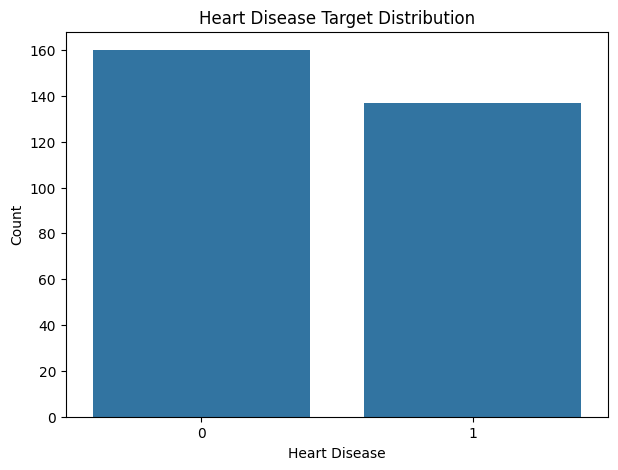


Features After Encoding:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  
0   1     0  
1   2     0  
2   0     0  
3   1     0  
4   0     0  

Number of Features:
13

Training Data Shape:
(237, 13)

Testing Data Shape:
(60, 13)

Decision Tree Training Completed.

DECISION TREE RESULTS
Accuracy: 0.8
Precision: 0.8200000000000001
Recall: 0.8
F1 Score: 0.7944444444444445

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.94      0.83        32
           1       0.90      0.64      0.

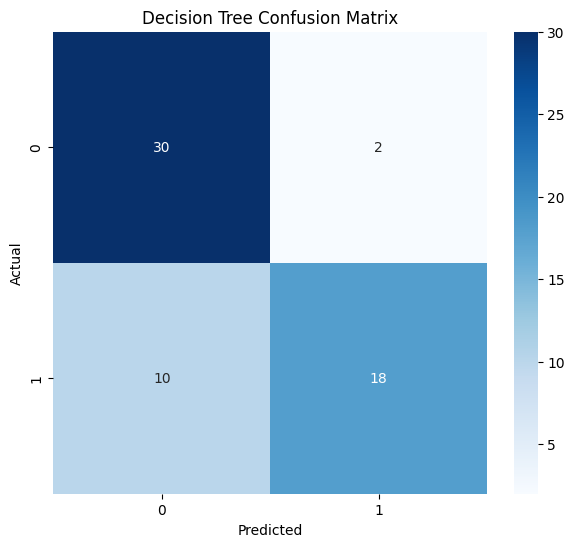


Feature Importance:
     Feature  Importance
2         cp    0.334819
9    oldpeak    0.196043
7    thalach    0.089115
11        ca    0.086901
1        sex    0.074209
10     slope    0.072809
0        age    0.049124
3   trestbps    0.048887
4       chol    0.032369
12      thal    0.015724
8      exang    0.000000
5        fbs    0.000000
6    restecg    0.000000


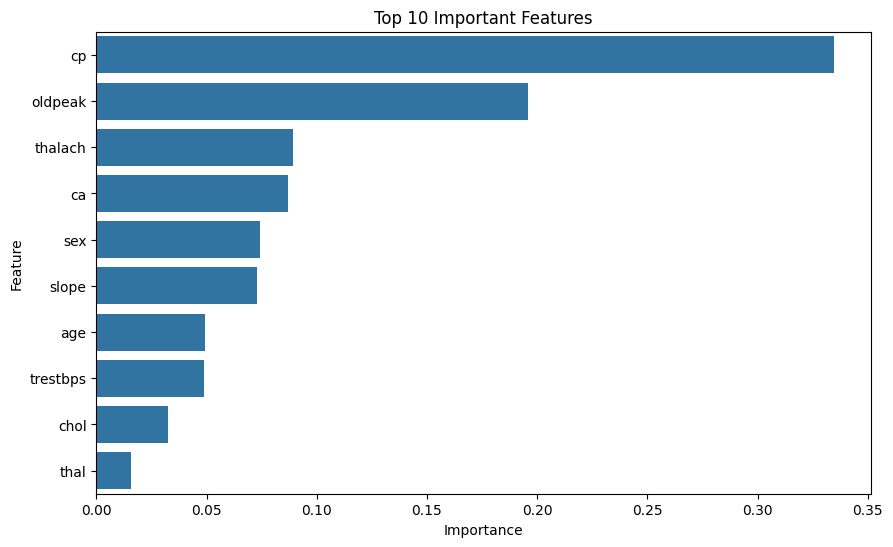

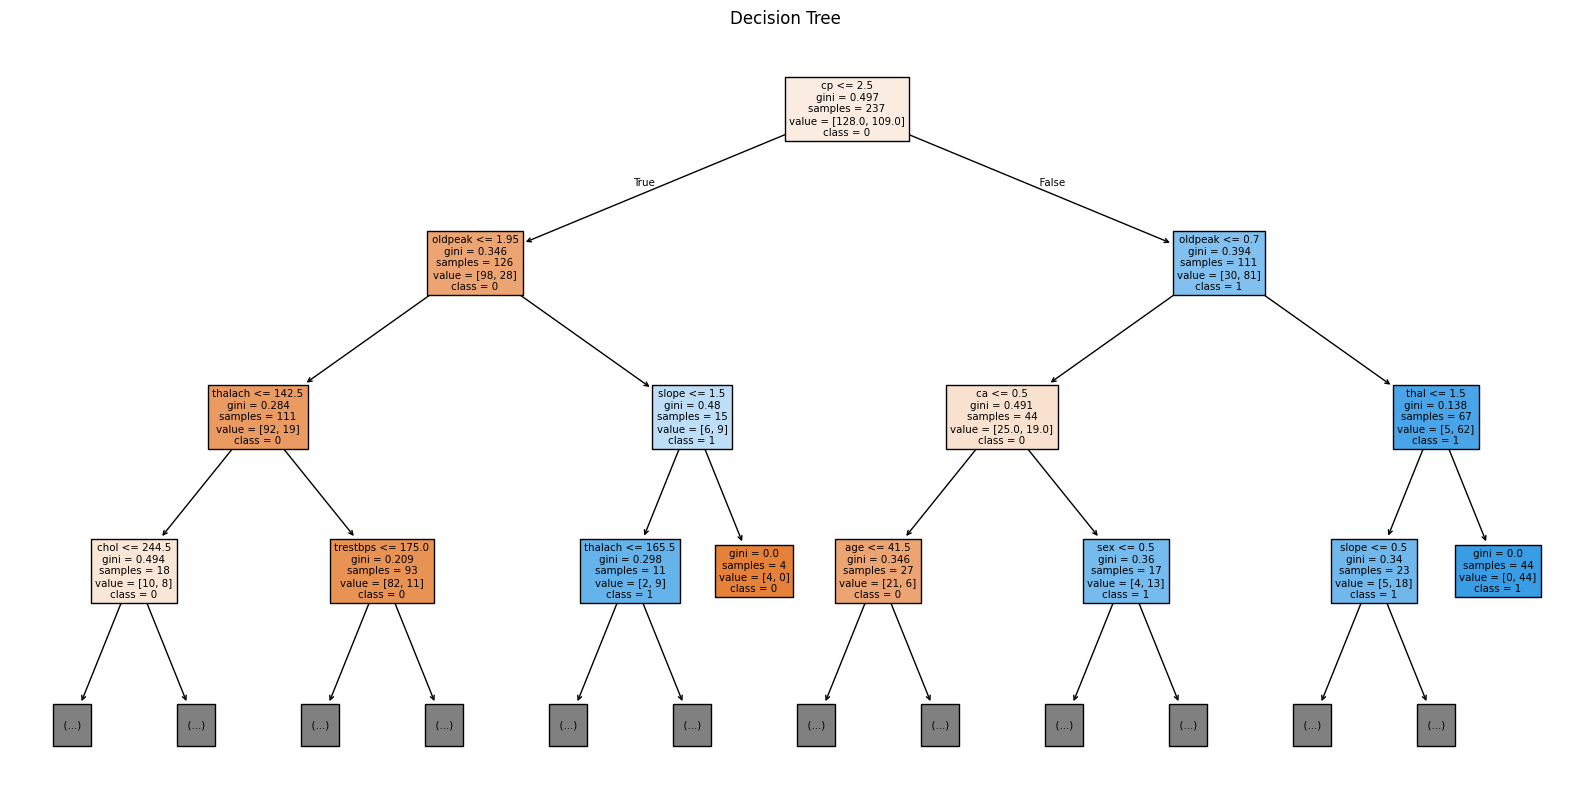


PROGRAM COMPLETED SUCCESSFULLY
Saved files:
1. heart_disease_decision_tree_predictions.csv
2. heart_disease_cleaned.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# ============================================================
# PROGRAM 8: HEART DISEASE
# DECISION TREE CLASSIFICATION
# ============================================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 2. Upload CSV
# ============================================================

print("Choose Heart Disease CSV file:")

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = pd.read_csv(filename)

# ============================================================
# 3. Display Dataset
# ============================================================

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

# ============================================================
# 4. Clean Column Names
# ============================================================

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("\nCleaned Columns:")
print(df.columns.tolist())

# ============================================================
# 5. Dataset Information
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

# ============================================================
# 6. Handle Missing Values
# ============================================================

# Numerical columns
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# ============================================================
# 7. Remove Duplicate Rows
# ============================================================

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df = df.drop_duplicates()

# ============================================================
# 8. Identify Target Column
# ============================================================

print("\nColumns:")
print(df.columns.tolist())

# ============================================================
# 9. Target Variable
# ============================================================

# Most versions of this dataset use 'condition'
if "condition" in df.columns:
    target = "condition"

elif "target" in df.columns:
    target = "target"

else:
    # Use the last column if target name is different
    target = df.columns[-1]

print("\nTarget Column:", target)

print("\nTarget Distribution:")
print(df[target].value_counts())

# ============================================================
# 10. Target Distribution Plot
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x=target
)

plt.title("Heart Disease Target Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

# ============================================================
# 11. Separate Features and Target
# ============================================================

X = df.drop(
    target,
    axis=1
)

y = df[target]

# ============================================================
# 12. Encode Categorical Variables
# ============================================================

X = pd.get_dummies(
    X,
    drop_first=True,
    dtype=int
)

print("\nFeatures After Encoding:")
print(X.head())

print("\nNumber of Features:")
print(X.shape[1])

# ============================================================
# 13. Train-Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

# ============================================================
# 14. Create Decision Tree
# ============================================================

model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=5,
    random_state=42
)

# ============================================================
# 15. Train Model
# ============================================================

model.fit(
    X_train,
    y_train
)

print("\nDecision Tree Training Completed.")

# ============================================================
# 16. Prediction
# ============================================================

y_pred = model.predict(
    X_test
)

# ============================================================
# 17. Accuracy
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\n================================")
print("DECISION TREE RESULTS")
print("================================")

print("Accuracy:", accuracy)

# ============================================================
# 18. Precision
# ============================================================

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Precision:", precision)

# ============================================================
# 19. Recall
# ============================================================

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Recall:", recall)

# ============================================================
# 20. F1 Score
# ============================================================

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("F1 Score:", f1)

# ============================================================
# 21. Classification Report
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred
    )
)

# ============================================================
# 22. Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

# ============================================================
# 23. Feature Importance
# ============================================================

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print("\nFeature Importance:")
print(importance)

# ============================================================
# 24. Feature Importance Plot
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()

# ============================================================
# 25. Visualize Decision Tree
# ============================================================

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=[
        str(c) for c in model.classes_
    ],
    filled=True,
    max_depth=3
)

plt.title("Decision Tree")
plt.show()

# ============================================================
# 26. Save Predictions
# ============================================================

result = X_test.copy()

result["Actual"] = y_test.values
result["Predicted"] = y_pred

result.to_csv(
    "heart_disease_decision_tree_predictions.csv",
    index=False
)

# ============================================================
# 27. Save Cleaned Dataset
# ============================================================

df.to_csv(
    "heart_disease_cleaned.csv",
    index=False
)

print("\n======================================")
print("PROGRAM COMPLETED SUCCESSFULLY")
print("======================================")

print("Saved files:")
print("1. heart_disease_decision_tree_predictions.csv")
print("2. heart_disease_cleaned.csv")

# Download predictions
files.download(
    "heart_disease_decision_tree_predictions.csv"
)